# Beszámoló

**Cross-cultural lab project - Female contribution to subsistence and exclusively female work groups in the SCCS**

Szerző: Owaimer Aisha

## Kutatási kérdés

Azok a társadalmak, ahol a nők nagyobb mértékben járulnak hozzá a megélhetéshez (subsistence), nagyobb valószínűséggel rendelkeznek-e közösségi szintű, kizárólag női munkacsoportokkal? A kérdés mögötti gondolat az, hogy ahol a nők gazdaságilag aktívabbak, ott nagyobb eséllyel szerveződnek önálló, formális munkacsoportokba is.

Másodlagos cél annak vizsgálata, hogy ez az összefüggés konzisztens-e a főbb földrajzi régiók között, vagy régiónként eltér.

## Adatforrás

A D-PLACE Standard Cross-Cultural Sample (SCCS) nyilvános adatbázisa: 186 társadalom Murdock és White (1969) mintájából.

## Változók

| Szerep | Változó | SCCS kód | Típus |
|---|---|---|---|
| Függő (DV) | Community-wide Exclusively Female Work Groups | SCCS588 | Ordinális kategorikus (1 = nincs, 2 = van) |
| Fő független (IV) | Average Female Contribution to Subsistence | SCCS826 | Folytonos (0-100%) |
| Kontroll | Agriculture - Contribution to Local Food Supply | SCCS3 | Ordinális (1-6) |
| Kontroll | Marital Residence | SCCS69 | Kategorikus (1-5) |
| Kontroll | Population Density | SCCS64 | Ordinális (1-7) |

Az elemzés **leíró jellegű** - a változók közötti kapcsolatokat vizsgáljuk, de kauzális következtetéseket nem vonunk le.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (8, 5)

## 1. Adat betöltése

Az adatok előfeldolgozása a `helper.ipynb` notebookban történt: letöltés a D-PLACE GitHub-ról, a releváns változók szűrése, a társadalom-metaadatok és a földrajzi régiók hozzárendelése, majd mentés TSV fájlokba. Itt ezeket a kész fájlokat olvassuk be.

In [ ]:
d_wide = pd.read_csv('d_wide.tsv', sep='\t')
d_long = pd.read_csv('d_long.tsv', sep='\t')

# Short column names for convenience
d_wide.columns = ['soc_id', 'society', 'Lat', 'Long', 'region',
                   'agriculture', 'female_subsistence', 'female_work_groups',
                   'marital_residence', 'pop_density']

print(f'Number of societies: {len(d_wide)}')
print(f'Regions: {d_wide["region"].value_counts().to_dict()}')
print()
d_wide.head(10)

Number of societies: 186
Regions: {'East Eurasia': 34, 'North America': 33, 'South America': 32, 'Insular Pacific': 31, 'Africa': 28, 'Circum-Mediterranean': 28}



,soc_id,society,Lat,Long,region,agriculture,female_subsistence,female_work_groups,marital_residence,pop_density
0,SCCS1,Nama,-27.50,17.00,Africa,1.0,26.0,NaN,3.0,1.0
1,SCCS10,Luguru,-6.83,37.67,Africa,6.0,40.0,NaN,1.0,7.0
2,SCCS100,Tikopia,-12.29,168.83,Insular Pacific,6.0,30.0,NaN,3.0,6.0
3,SCCS101,Bunlap,-15.95,168.22,Insular Pacific,6.0,NaN,1.0,3.0,4.0
4,SCCS102,Mbau Fijians,-18.00,178.58,Insular Pacific,4.0,28.0,NaN,3.0,7.0
5,SCCS103,Ajie,-21.33,165.67,Insular Pacific,5.0,47.0,NaN,3.0,3.0
6,SCCS104,Māori,-35.33,174.17,Insular Pacific,5.0,31.0,NaN,3.0,2.0
7,SCCS105,Marquesans,-8.92,-140.17,Insular Pacific,6.0,18.0,1.0,5.0,5.0
8,SCCS106,Upolu Samoans,-13.94,-171.77,Insular Pacific,6.0,33.0,NaN,3.0,6.0
9,SCCS107,Makin,3.38,172.99,Insular Pacific,6.0,41.0,NaN,3.0,6.0


## 2. Hiányzó értékek

Nem minden változó áll rendelkezésre minden társadalomnál. A fő elemzésbe csak azok a társadalmak kerülhetnek be, ahol mind a függő változó (SCCS588), mind a fő független változó (SCCS826) elérhető. A kontrollváltozók vizsgálatánál mindig az adott változón hiányzó esetek kerülnek kizárásra.

In [ ]:
print('Missing values per variable:')
for col in ['female_subsistence', 'female_work_groups', 'agriculture', 'marital_residence', 'pop_density']:
    n_miss = d_wide[col].isna().sum()
    print(f'  {col}: {n_miss} ({n_miss/len(d_wide)*100:.1f}%)')

# Main analysis sample: both SCCS826 and SCCS588 available
d_main = d_wide.dropna(subset=['female_subsistence', 'female_work_groups']).copy()
print(f'\nMain analysis sample: {len(d_main)} societies')

Missing values per variable:
  female_subsistence: 3 (1.6%)
  female_work_groups: 114 (61.3%)
  agriculture: 0 (0.0%)
  marital_residence: 1 (0.5%)
  pop_density: 2 (1.1%)

Main analysis sample: 70 societies


A legfontosabb megfigyelés itt az, hogy a függő változó (SCCS588, female work groups) a 186 társadalomból 114-nél (61.3%) hiányzik. Ez azt jelenti, hogy a fő elemzési minta mindössze 70 társadalomra szűkül. Ennek az az oka, hogy az SCCS588 változót egy későbbi kódolási projektben rögzítették, amely nem fedte le az összes SCCS társadalmat. A többi változó gyakorlatilag teljes: az SCCS826 (female subsistence) csupán 3 társadalomnál hiányzik, a kontrollváltozók pedig legfeljebb 1-2 helyen.

## 3. Leíró statisztikák

Az egyes változók eloszlásának áttekintése a teljes mintában. Ez segít megérteni az adatok általános szerkezetét, mielőtt a változók közötti kapcsolatokra térünk.

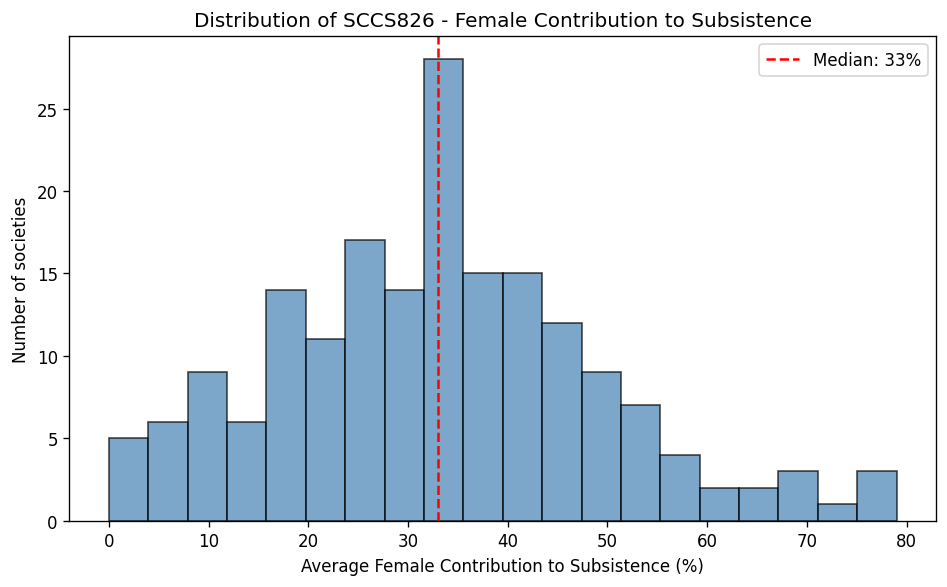

count    183.000000
mean      32.868852
std       16.549767
min        0.000000
25%       21.000000
50%       33.000000
75%       43.000000
max       79.000000
Name: female_subsistence, dtype: float64


In [ ]:
fig, ax = plt.subplots()
ax.hist(d_wide['female_subsistence'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Average Female Contribution to Subsistence (%)')
ax.set_ylabel('Number of societies')
ax.set_title('Distribution of SCCS826 - Female Contribution to Subsistence')
ax.axvline(d_wide['female_subsistence'].median(), color='red', linestyle='--',
           label=f'Median: {d_wide["female_subsistence"].median():.0f}%')
ax.legend()
plt.tight_layout()
plt.show()

print(d_wide['female_subsistence'].describe())

A női hozzájárulás (SCCS826) eloszlása közelítőleg szimmetrikus, 0% és 79% között szóródik. A medián 33%, ami azt jelenti, hogy a társadalmak felénél a nők a megélhetés harmadánál többet biztosítják. A szórás jelentős (~17 százalékpont), tehát a társadalmak között nagy a változatosság: vannak, ahol a nők szinte semmit nem járulnak hozzá (pl. pásztortársadalmak), és vannak, ahol a megélhetés nagyobb részét ők biztosítják (pl. egyes kertművelő társadalmak).

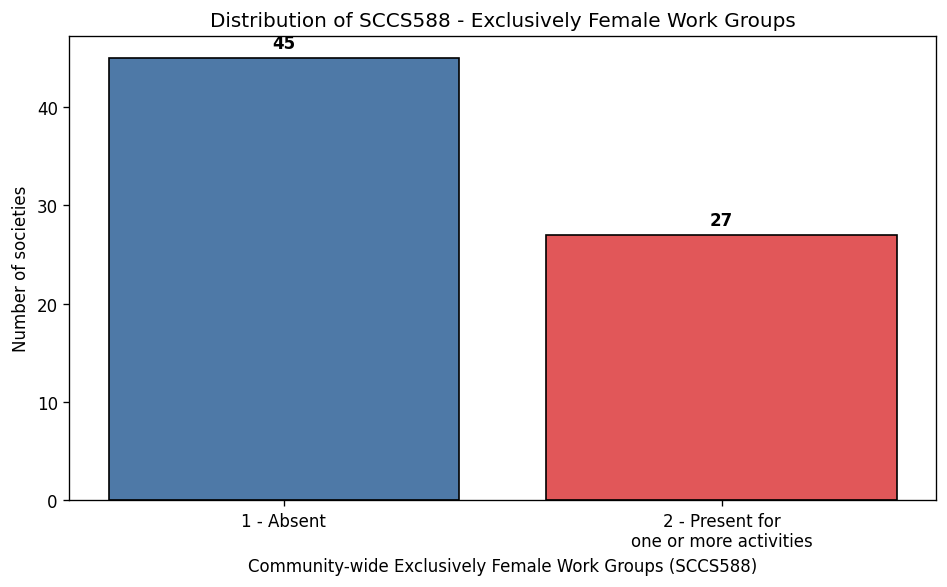

In [ ]:
fig, ax = plt.subplots()
counts = d_wide['female_work_groups'].value_counts().sort_index()
labels = {1.0: '1 - Absent', 2.0: '2 - Present for\none or more activities'}
ax.bar([labels.get(k, str(k)) for k in counts.index], counts.values, color=['#4e79a7', '#e15759'], edgecolor='black')
ax.set_xlabel('Community-wide Exclusively Female Work Groups (SCCS588)')
ax.set_ylabel('Number of societies')
ax.set_title('Distribution of SCCS588 - Exclusively Female Work Groups')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

A 72 társadalom közül, ahol az SCCS588 rendelkezésre áll, 45-ben (62.5%) nincsenek kizárólag női munkacsoportok (kód 1), és 27-ben (37.5%) vannak (kód 2). Az eloszlás tehát aszimmetrikus: a női munkacsoportok hiánya a gyakoribb állapot. Ez önmagában is érdekes - a legtöbb társadalomban a munkacsoportok vegyesek vagy férfidominanciájúak.

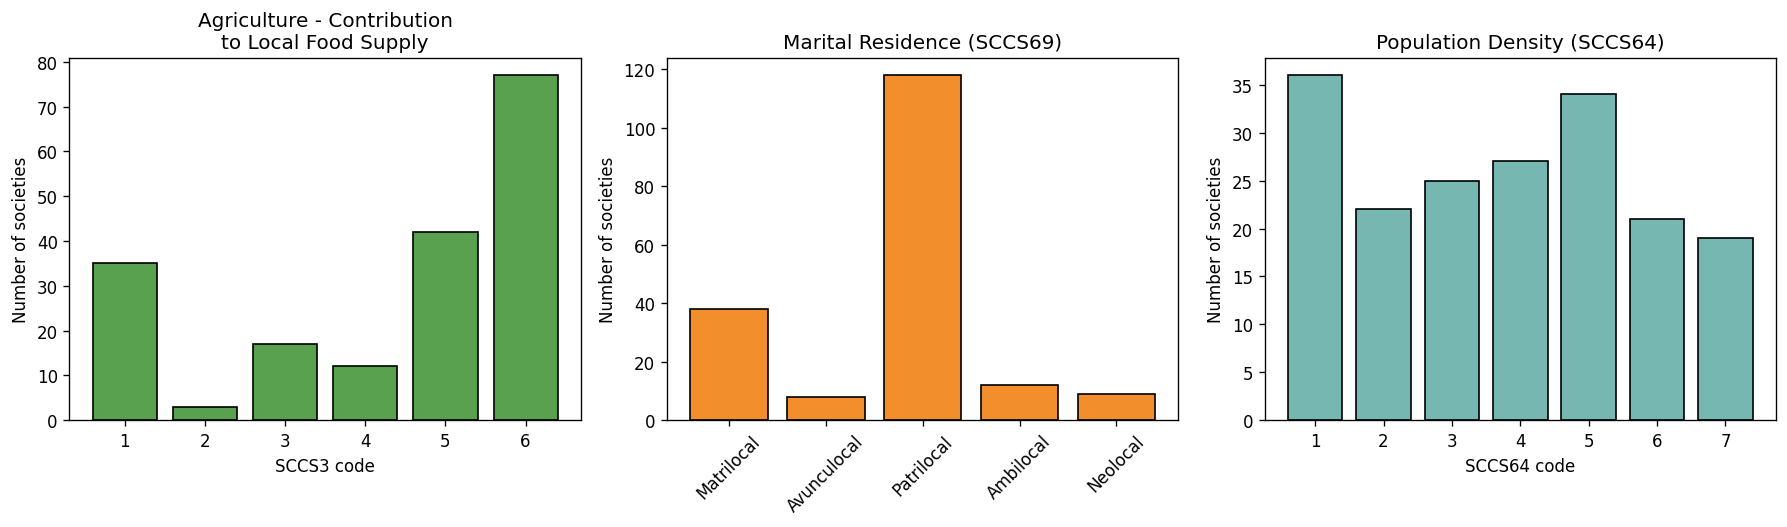

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
counts = d_wide['agriculture'].value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='#59a14f', edgecolor='black')
ax.set_xlabel('SCCS3 code')
ax.set_ylabel('Number of societies')
ax.set_title('Agriculture - Contribution\nto Local Food Supply')

ax = axes[1]
counts = d_wide['marital_residence'].dropna().value_counts().sort_index()
res_labels = {1: 'Matrilocal', 2: 'Avunculocal', 3: 'Patrilocal', 4: 'Ambilocal', 5: 'Neolocal'}
ax.bar([res_labels.get(int(k), str(k)) for k in counts.index], counts.values, color='#f28e2b', edgecolor='black')
ax.set_ylabel('Number of societies')
ax.set_title('Marital Residence (SCCS69)')
ax.tick_params(axis='x', rotation=45)

ax = axes[2]
counts = d_wide['pop_density'].dropna().value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='#76b7b2', edgecolor='black')
ax.set_xlabel('SCCS64 code')
ax.set_ylabel('Number of societies')
ax.set_title('Population Density (SCCS64)')

plt.tight_layout()
plt.show()

A három kontrollváltozó eloszlása:

- **Agriculture (SCCS3)**: U-alakú eloszlás - a társadalmak nagy része vagy egyáltalán nem mezőgazdasági (kód 1, ~50 társadalom), vagy döntően mezőgazdasági (kód 6, ~60 társadalom). Ez tükrözi, hogy az SCCS mintában mind a vadászó-gyűjtögető, mind a fejlett mezőgazdasági társadalmak jól képviseltek.

- **Marital Residence (SCCS69)**: Erős patrilokális dominancia - a társadalmak többsége (kb. 120) patrilokális (kód 3), ahol az új pár a férj családjánál telepedik le. A matrilokális (kód 1) és ambilikális (kód 4) elrendezés jóval ritkább.

- **Population Density (SCCS64)**: Viszonylag egyenletes eloszlás az alacsony és közepes sűrűségű kategóriák között, a legmagasabb kategória (kód 7, 500+ fő/négyzetmérföld) a leggyakoribb. Ez arra utal, hogy az SCCS minta a népsűrűség teljes spektrumát lefedi.

## 4. Fő kapcsolat: Female Contribution to Subsistence x Female Work Groups

A központi kérdés: különbözik-e a női hozzájárulás (SCCS826) eloszlása aszerint, hogy a társadalomban léteznek-e kizárólag női munkacsoportok (SCCS588)? Ha a hipotézis helyes, a női munkacsoportokkal rendelkező társadalmakban (SCCS588 = 2) magasabb SCCS826 értékeket várunk.

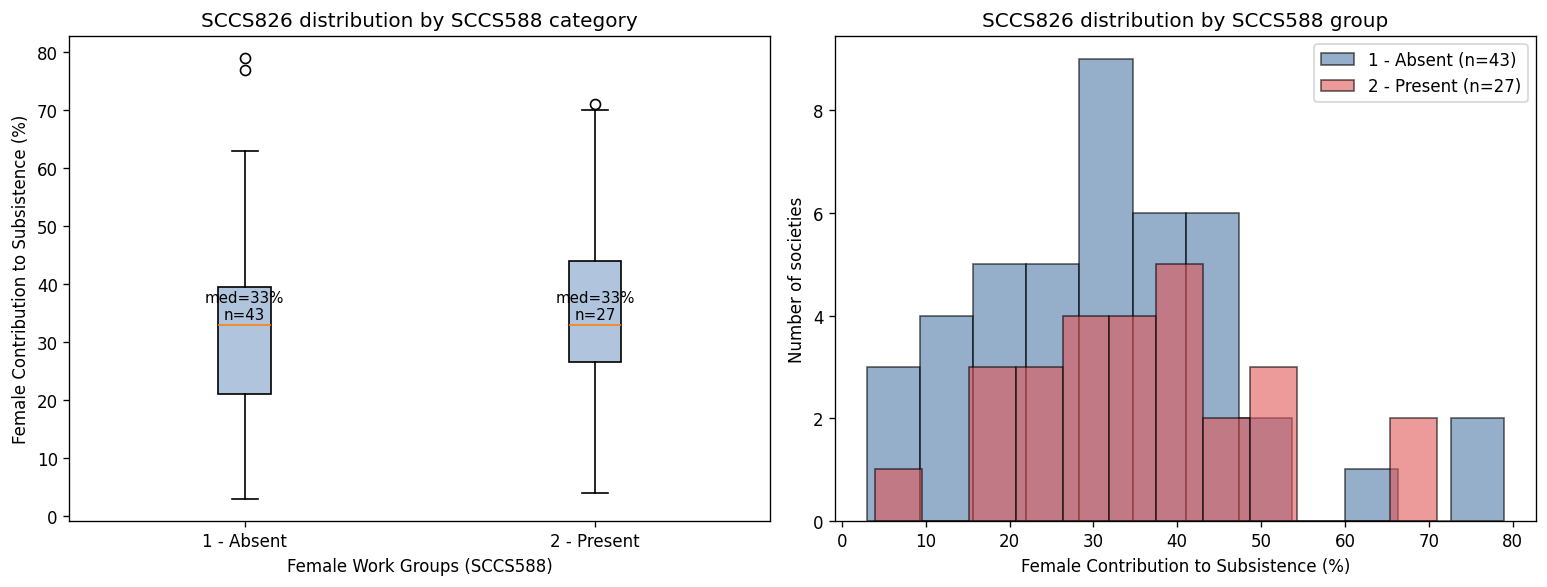

Summary statistics:
                    count  mean   std  min   25%   50%   75%   max
female_work_groups                                                
1.0                  43.0  32.0  16.6  3.0  21.0  33.0  39.5  79.0
2.0                  27.0  35.8  15.2  4.0  26.5  33.0  44.0  71.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
ax = axes[0]
groups = [d_main[d_main['female_work_groups'] == g]['female_subsistence'] for g in [1.0, 2.0]]
bp = ax.boxplot(groups, tick_labels=['1 - Absent', '2 - Present'], patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
ax.set_xlabel('Female Work Groups (SCCS588)')
ax.set_ylabel('Female Contribution to Subsistence (%)')
ax.set_title('SCCS826 distribution by SCCS588 category')
for i, g in enumerate(groups):
    ax.text(i + 1, g.median() + 1, f'med={g.median():.0f}%\nn={len(g)}', ha='center', fontsize=9)

# Overlapping histogram
ax = axes[1]
for val, label, color in [(1.0, '1 - Absent', '#4e79a7'), (2.0, '2 - Present', '#e15759')]:
    subset = d_main[d_main['female_work_groups'] == val]['female_subsistence']
    ax.hist(subset, bins=12, alpha=0.6, label=f'{label} (n={len(subset)})', color=color, edgecolor='black')
ax.set_xlabel('Female Contribution to Subsistence (%)')
ax.set_ylabel('Number of societies')
ax.set_title('SCCS826 distribution by SCCS588 group')
ax.legend()

plt.tight_layout()
plt.show()

print('Summary statistics:')
print(d_main.groupby('female_work_groups')['female_subsistence'].describe().round(1))

A boxplot és a hisztogram alapján a két csoport SCCS826-eloszlása nagyrészt átfedi egymást. A mediánok azonosak (33%-33%), és bár az átlagokban van egy kis eltérés a hipotézis irányába (32.0% vs. 35.8%, +3.8 százalékpont), ez a különbség a nagy szóródáshoz képest csekély.

A hisztogramon jól látszik, hogy mindkét csoport eloszlása hasonló alakú - nincs határozott eltolódás a női munkacsoportos társadalmak (piros) felé. Az interkvartilis tartományok is jelentősen átfednek (a boxploton a dobozok nagyjából ugyanott helyezkednek el).

Összességében az aggregált leíró adatok nem támogatják egyértelműen a hipotézist: a női hozzájárulás mértéke önmagában nem különbözteti meg jól a két csoportot.

## 5. Kontrollváltozók és SCCS588

A fő kapcsolat értelmezéséhez hasznos megvizsgálni, hogy a három kontrollváltozó - mezőgazdaság (SCCS3), házassági lakóhely (SCCS69) és népsűrűség (SCCS64) - hogyan kapcsolódik a női munkacsoportok jelenlétéhez. Ez segít megérteni, milyen típusú társadalmakban jellemzőbbek a női munkacsoportok.

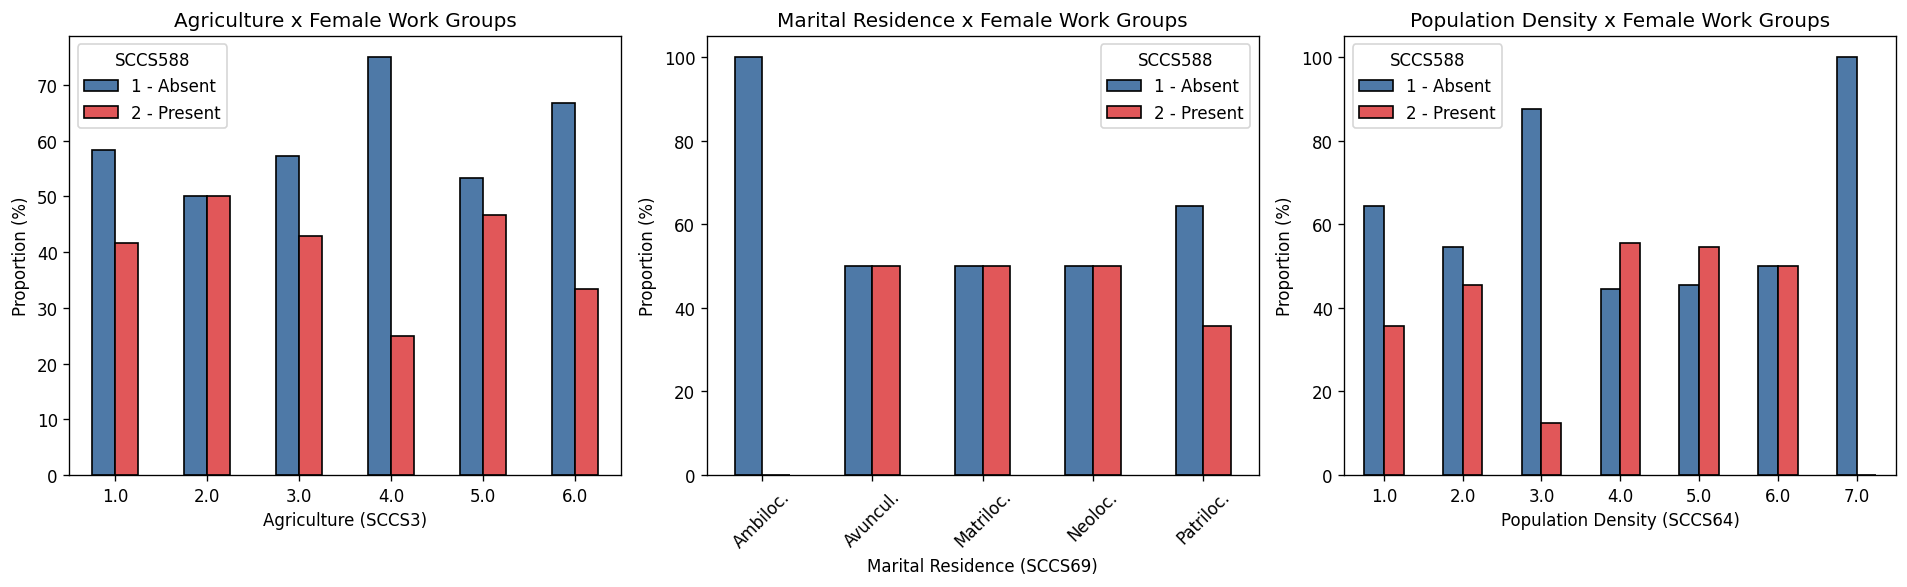

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Agriculture x Female Work Groups
ax = axes[0]
d_temp = d_main.dropna(subset=['agriculture'])
ct = pd.crosstab(d_temp['agriculture'], d_temp['female_work_groups'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#4e79a7', '#e15759'], edgecolor='black')
ax.set_xlabel('Agriculture (SCCS3)')
ax.set_ylabel('Proportion (%)')
ax.set_title('Agriculture x Female Work Groups')
ax.legend(['1 - Absent', '2 - Present'], title='SCCS588')
ax.tick_params(axis='x', rotation=0)

# Marital Residence x Female Work Groups
ax = axes[1]
d_temp = d_main.dropna(subset=['marital_residence'])
res_labels = {1: 'Matriloc.', 2: 'Avuncul.', 3: 'Patriloc.', 4: 'Ambiloc.', 5: 'Neoloc.'}
d_temp = d_temp.copy()
d_temp['mr_label'] = d_temp['marital_residence'].map(res_labels)
ct = pd.crosstab(d_temp['mr_label'], d_temp['female_work_groups'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#4e79a7', '#e15759'], edgecolor='black')
ax.set_xlabel('Marital Residence (SCCS69)')
ax.set_ylabel('Proportion (%)')
ax.set_title('Marital Residence x Female Work Groups')
ax.legend(['1 - Absent', '2 - Present'], title='SCCS588')
ax.tick_params(axis='x', rotation=45)

# Population Density x Female Work Groups
ax = axes[2]
d_temp = d_main.dropna(subset=['pop_density'])
ct = pd.crosstab(d_temp['pop_density'], d_temp['female_work_groups'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#4e79a7', '#e15759'], edgecolor='black')
ax.set_xlabel('Population Density (SCCS64)')
ax.set_ylabel('Proportion (%)')
ax.set_title('Population Density x Female Work Groups')
ax.legend(['1 - Absent', '2 - Present'], title='SCCS588')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

A kontrollváltozók vizsgálata néhány érdekes mintázatot mutat:

- **Agriculture (SCCS3)**: A döntően mezőgazdasági társadalmakban (kód 5-6) gyakoribbak a női munkacsoportok, mint a nem-mezőgazdasági társadalmakban (kód 1-2). Ez összhangban van azzal a kulturális antropológiai megfigyeléssel, hogy a mezőgazdaságban, különösen a kertművelésben, a nők gyakran szervezett csoportokban dolgoznak.

- **Marital Residence (SCCS69)**: A matrilokális társadalmakban (ahol az új pár a feleség családjánál telepedik le) a női munkacsoportok feltűnően gyakoribbak, mint a patrilokális társadalmakban. Ez logikus: matrilokális berendezkedésnél a rokon nők földrajzilag közel maradnak egymáshoz, ami megkönnyíti a közös munkaszervezést.

- **Population Density (SCCS64)**: A kapcsolat kevésbé egyértelmű. A közepes és magas népsűrűségű társadalmakban talán valamivel gyakoribbak a női munkacsoportok, de a mintázat nem konzisztens a kategóriák között.

Ezek a megfigyelések arra utalnak, hogy a női munkacsoportok jelenlétét nem csupán a női hozzájárulás mértéke, hanem a társadalom gazdasági szerkezete és rokonsági rendszere is befolyásolja.

## 6. Regionális elemzés

A fenti összesített kép mögött a világ különböző részein eltérő mintázatok húzódhatnak meg. Az SCCS hat Murdock-féle világrégiót fed le. A regionális elemzést az öt legnagyobb almintával rendelkező régióra korlátozzuk, hogy a csoportméret lehetővé tegye az összehasonlítást.

In [ ]:
print('Sample size per region (main analysis sample):')
region_counts = d_main['region'].value_counts()
print(region_counts.to_string())
print()

# Top 5 regions by sample size
top_regions = region_counts.head(5).index.tolist()
d_regional = d_main[d_main['region'].isin(top_regions)].copy()
print(f'Selected regions: {top_regions}')
print(f'Societies in regional analysis: {len(d_regional)}')

Sample size per region (main analysis sample):
region
South America           14
North America           13
Insular Pacific         11
East Eurasia            11
Circum-Mediterranean    11
Africa                  10

Selected regions: ['South America', 'North America', 'Insular Pacific', 'East Eurasia', 'Circum-Mediterranean']
Societies in regional analysis: 60


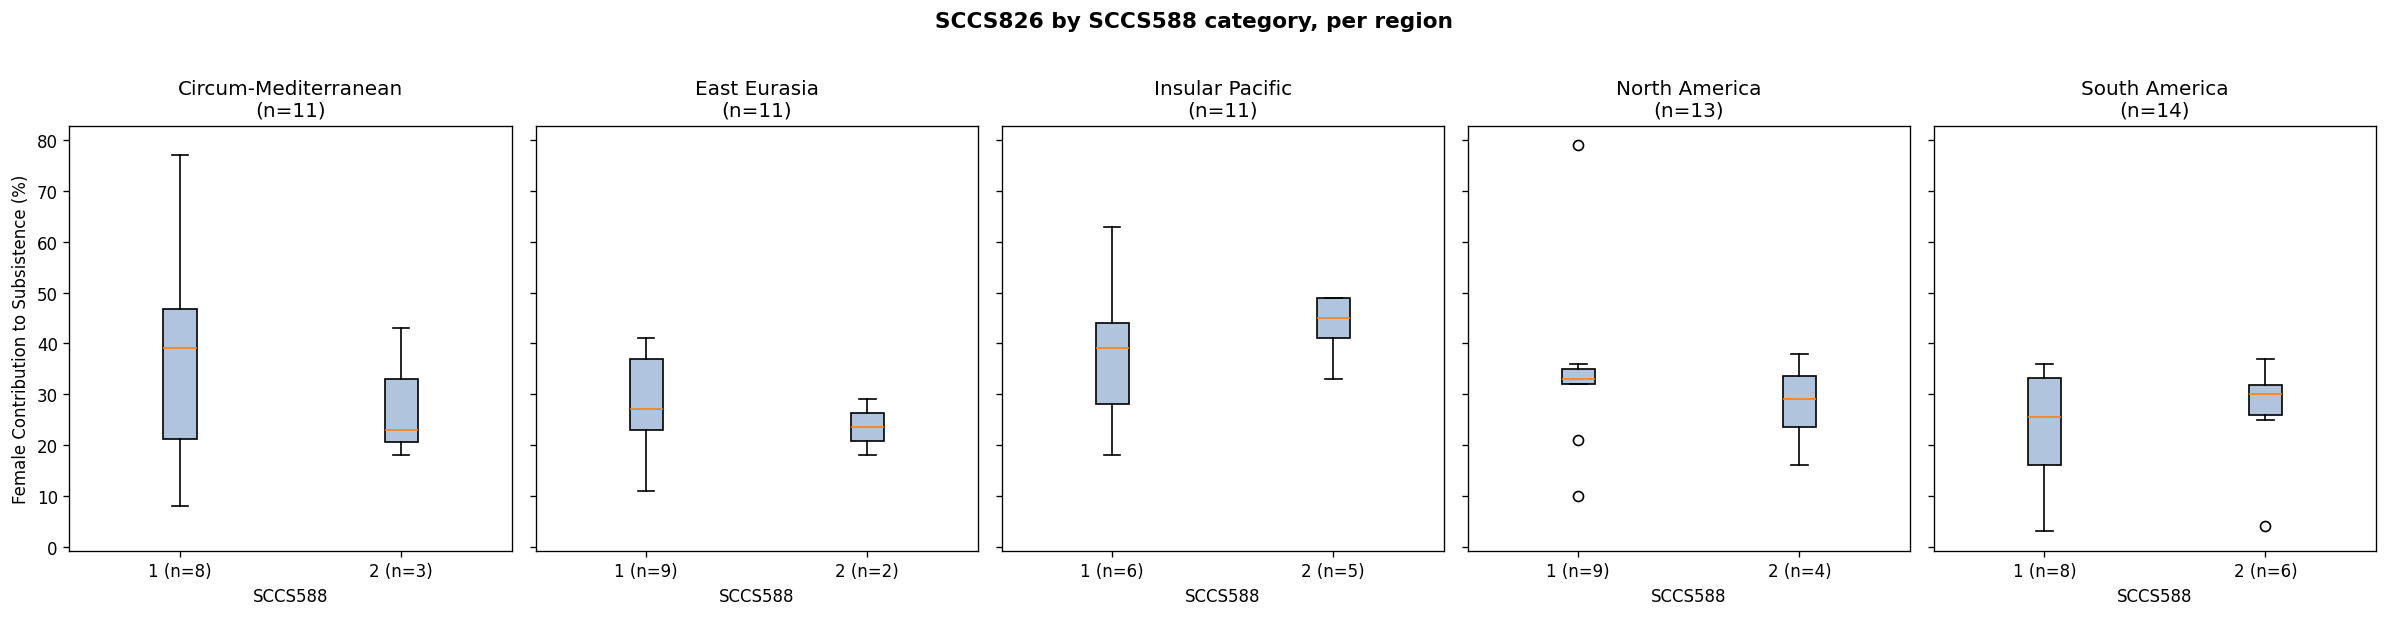

In [ ]:
fig, axes = plt.subplots(1, len(top_regions), figsize=(4 * len(top_regions), 5), sharey=True)

for i, region in enumerate(sorted(top_regions)):
    ax = axes[i] if len(top_regions) > 1 else axes
    d_reg = d_regional[d_regional['region'] == region]
    groups = []
    labels_used = []
    for val in [1.0, 2.0]:
        subset = d_reg[d_reg['female_work_groups'] == val]['female_subsistence']
        if len(subset) > 0:
            groups.append(subset)
            labels_used.append(f'{int(val)} (n={len(subset)})')
        else:
            groups.append(pd.Series(dtype=float))
            labels_used.append(f'{int(val)} (n=0)')

    bp = ax.boxplot(groups, tick_labels=labels_used, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(f'{region}\n(n={len(d_reg)})')
    ax.set_xlabel('SCCS588')
    if i == 0:
        ax.set_ylabel('Female Contribution to Subsistence (%)')

plt.suptitle('SCCS826 by SCCS588 category, per region', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

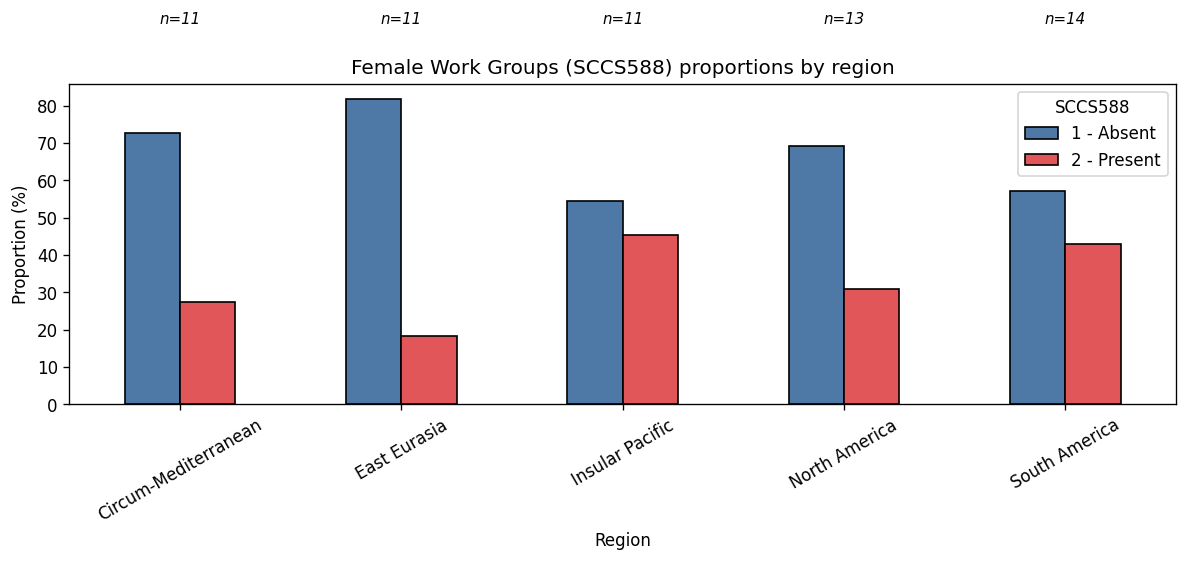

Regional summary (SCCS826 median by SCCS588 group):
                                         median  count
region               female_work_groups               
Circum-Mediterranean 1.0                   39.0      8
                     2.0                   23.0      3
East Eurasia         1.0                   27.0      9
                     2.0                   23.5      2
Insular Pacific      1.0                   39.0      6
                     2.0                   45.0      5
North America        1.0                   33.0      9
                     2.0                   29.0      4
South America        1.0                   25.5      8
                     2.0                   30.0      6


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(d_regional['region'], d_regional['female_work_groups'], normalize='index') * 100
ct = ct.reindex(sorted(top_regions))
ct.plot(kind='bar', ax=ax, color=['#4e79a7', '#e15759'], edgecolor='black')
ax.set_xlabel('Region')
ax.set_ylabel('Proportion (%)')
ax.set_title('Female Work Groups (SCCS588) proportions by region')
ax.legend(['1 - Absent', '2 - Present'], title='SCCS588')
ax.tick_params(axis='x', rotation=30)

for i, region in enumerate(sorted(top_regions)):
    n = len(d_regional[d_regional['region'] == region])
    ax.text(i, 102, f'n={n}', ha='center', fontsize=9, fontstyle='italic')

plt.tight_layout()
plt.show()

print('Regional summary (SCCS826 median by SCCS588 group):')
summary = d_regional.groupby(['region', 'female_work_groups'])['female_subsistence'].agg(['median', 'count'])
print(summary.round(1))

A regionális bontás vegyes képet mutat, ami az összefüggés kontextusfüggőségére utal:

- **Insular Pacific**: Ez az egyetlen régió, ahol a hipotézis irányába mutató mintázat látható. A női munkacsoportokkal rendelkező társadalmakban a medián női hozzájárulás magasabb (45%) mint a nélkülük (39%). Ezt magyarázhatja, hogy a csendes-óceáni szigetvilágban a kertművelés és halászat gyakran nemi munkamegosztás szerint szerveződik.

- **Circum-Mediterranean és East Eurasia**: Ezekben a régiókban a tendencia **fordított** - a női munkacsoportok nélküli társadalmakban magasabb a női hozzájárulás mediánja. Ez arra utalhat, hogy ezekben a régiókban más kulturális tényezők (pl. a mezőgazdaság típusa, a rokonsági rendszer) erősebben befolyásolják a munkacsoportok szerveződését.

- **North America és South America**: A különbségek minimálisak, nem rajzolódik ki határozott mintázat.

- **A régiós arányok**: A grouped bar plot mutatja, hogy a női munkacsoportok előfordulási gyakorisága régiónként is eltér. Az Insular Pacific-ben és South America-ban a leggyakoribbak (40-50%), míg az East Eurasia-ban a legritkábbak (~18%).

Fontos megjegyezni, hogy a régiónkénti alminták kicsik (10-14 társadalom), azon belül is a két SCCS588-kategória között oszlanak meg, tehát az egyes régiós mintázatokat óvatosan kell értelmezni.

## 7. Összefoglalás

In [ ]:
n_total = len(d_wide)
n_main = len(d_main)
g1 = d_main[d_main['female_work_groups'] == 1.0]['female_subsistence']
g2 = d_main[d_main['female_work_groups'] == 2.0]['female_subsistence']

print(f"""=== SUMMARY ===

Sample: {n_total} SCCS societies, of which {n_main} have data on both SCCS826 and SCCS588.
The dependent variable (SCCS588) has substantial missingness: {d_wide['female_work_groups'].isna().sum()} societies ({d_wide['female_work_groups'].isna().mean()*100:.0f}%) missing.

Main result:
- SCCS588 = 1 (no exclusively female work groups): n = {len(g1)}, mean = {g1.mean():.1f}%, median = {g1.median():.0f}%
- SCCS588 = 2 (exclusively female work groups present): n = {len(g2)}, mean = {g2.mean():.1f}%, median = {g2.median():.0f}%
- Difference in means: {g2.mean() - g1.mean():+.1f} pp, in medians: {g2.median() - g1.median():+.0f} pp

The overall descriptive results show a weak, inconclusive association: the medians are
essentially identical, with a small difference in means in the direction of the hypothesis.

The regional picture is mixed: in some regions (e.g. Insular Pacific) the pattern is
consistent with the hypothesis, while in others (e.g. Circum-Mediterranean, East Eurasia)
the trend is reversed.

The analysis is descriptive; no causal conclusions are drawn.
""")

=== SUMMARY ===

Sample: 186 SCCS societies, of which 70 have data on both SCCS826 and SCCS588.
The dependent variable (SCCS588) has substantial missingness: 114 societies (61%) missing.

Main result:
- SCCS588 = 1 (no exclusively female work groups): n = 43, mean = 32.0%, median = 33%
- SCCS588 = 2 (exclusively female work groups present): n = 27, mean = 35.8%, median = 33%
- Difference in means: +3.8 pp, in medians: +0 pp

The overall descriptive results show a weak, inconclusive association: the medians are
essentially identical, with a small difference in means in the direction of the hypothesis.

The regional picture is mixed: in some regions (e.g. Insular Pacific) the pattern is
consistent with the hypothesis, while in others (e.g. Circum-Mediterranean, East Eurasia)
the trend is reversed.

The analysis is descriptive; no causal conclusions are drawn.



### Eredmények értékelése

Az elemzés három fő megállapítással zárható:

**1. A fő hipotézist az összesített adatok nem támasztják alá egyértelműen.** A női megélhetési hozzájárulás (SCCS826) mediánja azonos (33%) a két SCCS588-csoportban. Az átlagokban van egy kis eltérés a hipotézis irányába (+3.8 százalékpont), de ez a nagy szóráson belül elhanyagolható.

**2. A kontrollváltozók gazdagítják a képet.** A mezőgazdaság típusa (SCCS3) és különösen a házassági lakóhely (SCCS69) erősebben kapcsolódik a női munkacsoportok jelenlétéhez, mint önmagában a női hozzájárulás mértéke. Ez arra utal, hogy a női munkacsoportok kialakulása összetett jelenség, amelyet a társadalom gazdasági és rokonsági szerkezete együttesen alakít.

**3. A regionális mintázatok eltérnek.** Az összefüggés nem univerzális: az Insular Pacific régióban a hipotézissel összhangban áll, máshol fordított vagy semleges. Ez arra figyelmeztet, hogy az ilyen cross-cultural összefüggések értelmezésénél figyelembe kell venni a regionális kontextust.

**Korlátok**: A fő elemzési minta viszonylag kicsi (n = 70), és a régiónkénti alminták még kisebbek. A függő változó (SCCS588) magas hiányzási aránya (61%) korlátozza az eredmények általánosíthatóságát. Az elemzés kizárólag leíró jellegű, sem a vizsgált változók közötti ok-okozati kapcsolatokra, sem harmadik változók hatására nem kontrollálunk statisztikai modellezéssel.

## Hivatkozások

Kirby, K. R., Gray, R. D., Greenhill, S. J., Jordan, F. M., Gomes-Ng, S., Bibiko, H.-J., Blasi, D. E., Botero, C. A., Bowern, C., Ember, C. R., Leehr, D., Low, B. S., McCarter, J., Divale, W., & Gavin, M. C. (2016). D-PLACE: A global database of cultural, linguistic and environmental diversity. *PLOS ONE, 11*(7), e0158391. https://doi.org/10.1371/journal.pone.0158391

Murdock, G. P., & Morrow, D. O. (1970). Subsistence economy and supportive practices: Cross-cultural codes 1. *Ethnology, 9*(3), 302–330. https://doi.org/10.2307/3773028

Murdock, G. P., & White, D. R. (1969). Standard Cross-Cultural Sample. *Ethnology, 8*(4), 329–369. https://doi.org/10.2307/3772907

Murdock, G. P., & Wilson, S. F. (1972). Settlement patterns and community organization: Cross-cultural codes 3. *Ethnology, 11*(3), 254–295. https://doi.org/10.2307/3773219

### Szoftver

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

### Előregisztráció

A hipotézist és az elemzési tervet előzetesen regisztráltuk az AsPredicted platformon: https://aspredicted.org/rh3dn9.pdf